# Gaussian Mixture Models (GMM)

In this notebook we explore **Gaussian Mixture Models**, a probabilistic clustering algorithm.

Unlike K-Means, which assigns each point to a single cluster, GMM performs **soft clustering**, meaning each point belongs to clusters with different probabilities.

We will demonstrate:

- Soft clustering with probabilities
- Elliptical cluster modeling
- Comparison with K-Means
- Visualization of Gaussian contours

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

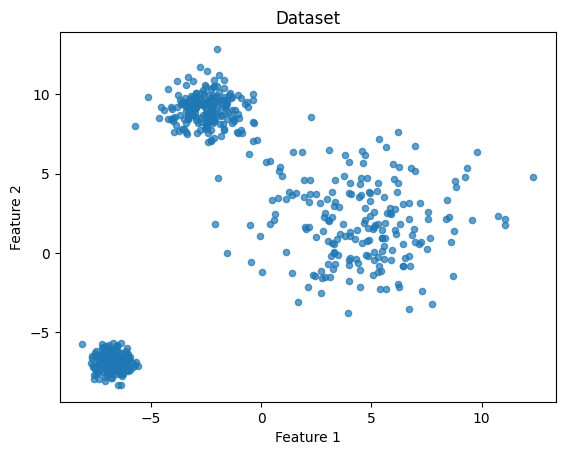

In [2]:
X, y = make_blobs(
    n_samples=600,
    centers=3,
    cluster_std=[1.0, 2.5, 0.5],
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1], s=20, alpha=0.7)
plt.title("Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

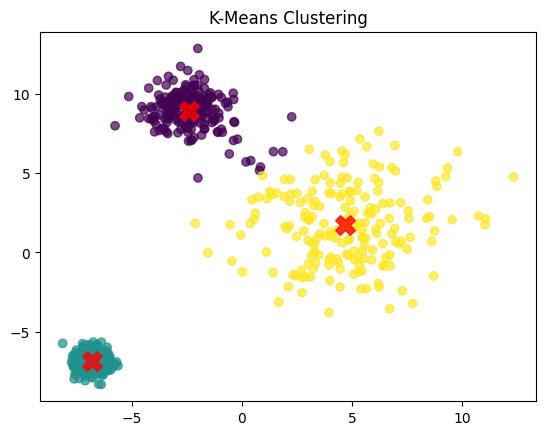

In [3]:
kmeans = KMeans(n_clusters=3, random_state=42)

labels_kmeans = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels_kmeans, cmap="viridis", alpha=0.7)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c="red",
    marker="X",
    s=200,
    alpha=0.8
)

plt.title("K-Means Clustering")
plt.show()

K-Means partitions data using **distance to centroids**.

This assumes clusters are **spherical** and equally sized.

In [4]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)

gmm.fit(X)

labels_gmm = gmm.predict(X)

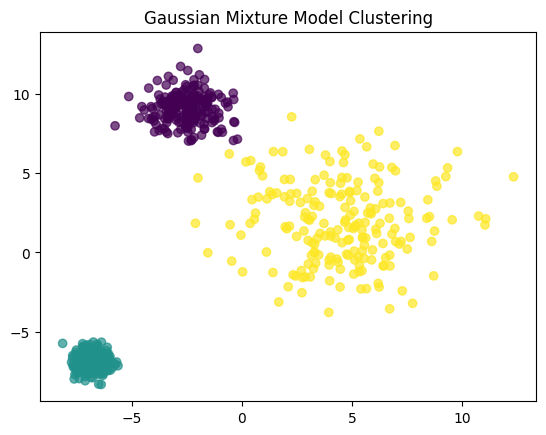

In [5]:
plt.scatter(X[:,0], X[:,1], c=labels_gmm, cmap="viridis", alpha=0.7)
plt.title("Gaussian Mixture Model Clustering")
plt.show()

Unlike K-Means, GMM models clusters as **Gaussian distributions**.

This allows clusters to become **elliptical** rather than spherical.

In [15]:
probs = gmm.predict_proba(X)

probs[:10]

array([[1.05748293e-029, 3.55654694e-125, 1.00000000e+000],
       [7.89935674e-065, 9.99999997e-001, 2.79861172e-009],
       [1.21347767e-033, 0.00000000e+000, 1.00000000e+000],
       [2.42774921e-064, 9.99999862e-001, 1.37925730e-007],
       [9.99738454e-001, 1.42844211e-205, 2.61546069e-004],
       [9.99894403e-001, 2.82392680e-216, 1.05597413e-004],
       [2.68502228e-001, 2.17574071e-181, 7.31497772e-001],
       [9.99781689e-001, 9.22347901e-243, 2.18311386e-004],
       [2.17635564e-052, 0.00000000e+000, 1.00000000e+000],
       [1.23696716e-034, 2.99235961e-236, 1.00000000e+000]])

Each row contains the **probability that the point belongs to each cluster**.

Example output:

[1.05748293e-029, 3.55654694e-125, 1.00000000e+000]

Meaning the point most likely belongs to cluster 3.

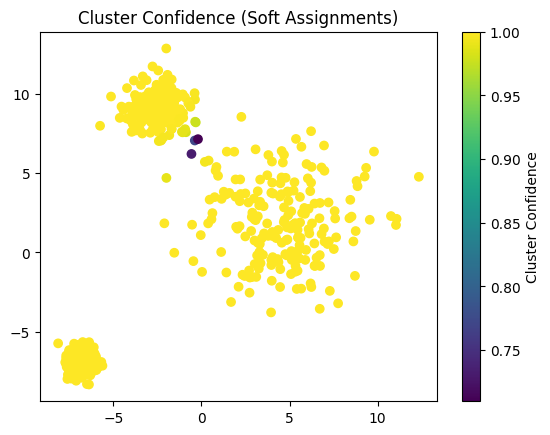

In [16]:
confidence = probs.max(axis=1)

plt.scatter(X[:,0], X[:,1], c=confidence, cmap="viridis")
plt.colorbar(label="Cluster Confidence")
plt.title("Cluster Confidence (Soft Assignments)")
plt.show()

Points near cluster centers have **high confidence**.

Points near boundaries show **uncertainty** between clusters.

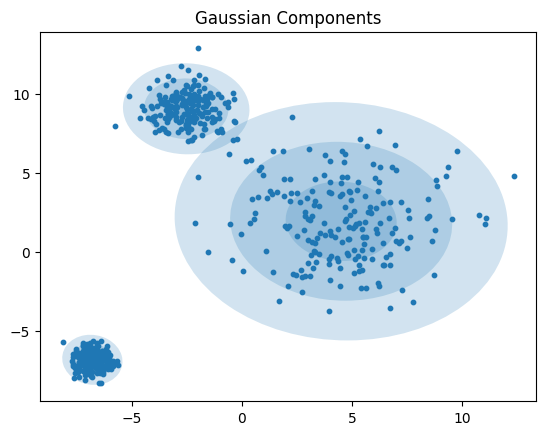

In [22]:
def draw_ellipse(position, covariance, ax=None, **kwargs):
    from matplotlib.patches import Ellipse
    
    ax = ax or plt.gca()
    
    if covariance.shape == (2,2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1,0], U[0,0]))
        width, height = 2*np.sqrt(s)
    else:
        angle = 0
        width, height = 2*np.sqrt(covariance)
    
    for nsig in range(1,4):
        ax.add_patch(
            Ellipse(xy=position, width=nsig*width, height=nsig*height, angle=angle, **kwargs)
        )

plt.scatter(X[:,0], X[:,1], s=10)

for pos, covar in zip(gmm.means_, gmm.covariances_):
    draw_ellipse(pos, covar, alpha=0.2)

plt.title("Gaussian Components")
plt.show()

### Gaussian Component Interpretation

Each ellipse represents a Gaussian component learned by the model.

The ellipse orientation and size are determined by the covariance matrix, allowing GMM to model **elliptical clusters**, unlike K-Means which assumes spherical clusters.

# Key Takeaways

Gaussian Mixture Models extend clustering beyond K-Means.

Key differences:

| Algorithm | Cluster Shape | Assignment |
|----------|---------------|-----------|
| K-Means | spherical | hard |
| GMM | elliptical | soft |

Advantages of GMM:

• Can model clusters with different shapes and sizes  
• Provides probability estimates for cluster membership  
• Captures uncertainty near cluster boundaries  

However, GMM requires careful selection of the number of components.